# F Distribution

The **F distribution** is the ratio of two independent chi-square variables divided by their degrees of freedom. It is right-skewed, positive, and is the foundation of **ANOVA** and regression **F-tests** for comparing variances.

| Property | Value |
|---|---|
| **Parameters** | $\nu_1$ (numerator df), $\nu_2$ (denominator df) |
| **Support** | $(0, +\infty)$ |
| **Definition** | $F = \dfrac{\chi^2(\nu_1)/\nu_1}{\chi^2(\nu_2)/\nu_2}$ |
| **Mean** | $\nu_2/(\nu_2-2)$ for $\nu_2 > 2$ |
| **Mode** | $\dfrac{\nu_1-2}{\nu_1} \cdot \dfrac{\nu_2}{\nu_2+2}$ for $\nu_1 > 2$ |
| **Skewness** | Right-skewed (positive) |
| **Reciprocal** | If $X \sim F(\nu_1,\nu_2)$, then $1/X \sim F(\nu_2,\nu_1)$ |
| **Primary use** | ANOVA, regression F-test, testing equality of variances |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the F Distribution

### Panel 1 — PDF: Shape by Degrees of Freedom
Each curve shows the **PDF** of $F(\nu_1, \nu_2)$ for different degree-of-freedom combinations. All F distributions are right-skewed and supported on $(0, \infty)$; they become more symmetric as both $\nu_1$ and $\nu_2$ increase.

### Panel 2 — Critical Values $F_{0.95}$ vs $\nu_2$
The **upper 5% critical value** decreases as the denominator $\nu_2$ increases (more information in the denominator). Different lines correspond to different numerator $\nu_1$ values, showing that higher $\nu_1$ also lowers the critical value.

### Panel 3 — ANOVA F-Test Demonstration
The $F(2,87)$ null distribution is shown with the $\alpha=0.05$ rejection region (red) and the observed F-statistic (orange line). When one group has a different mean, the observed F falls in the rejection region, correctly rejecting $H_0$.


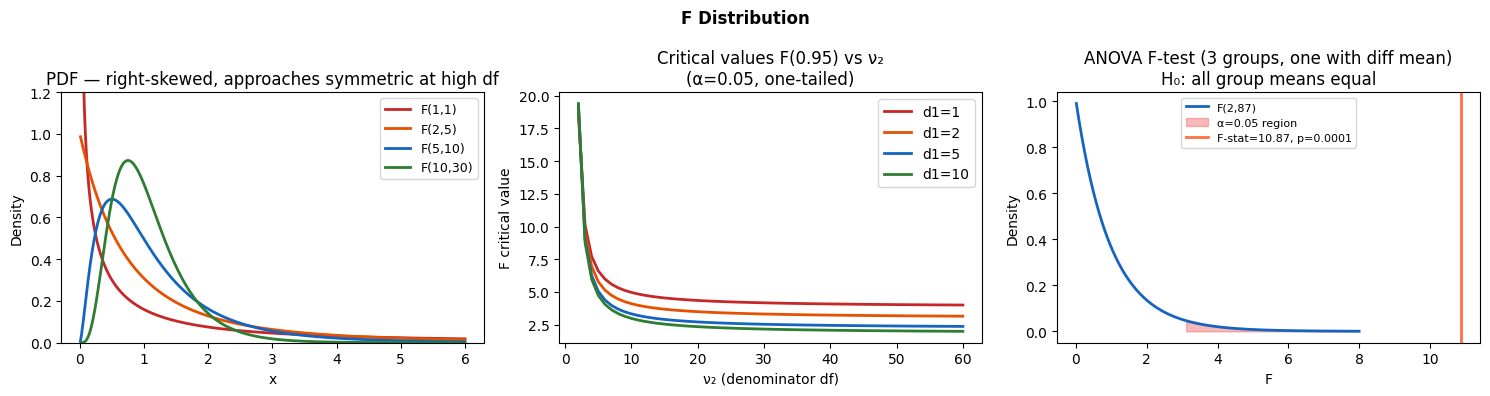

ANOVA: F=10.872, p=0.00006
Critical F(0.95, 2, 87) = 3.101
Group means: G1=9.62, G2=11.76, G3=10.03


In [2]:
x = np.linspace(0.01, 6, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('F Distribution', fontsize=12, fontweight='bold')

# PDF — various (d1, d2)
for d1, d2, color, label in [(1,  1,  '#C62828', 'F(1,1)'),
                               (2,  5,  '#E65100', 'F(2,5)'),
                               (5,  10, '#1565C0', 'F(5,10)'),
                               (10, 30, '#2E7D32', 'F(10,30)')]:
    axes[0].plot(x, stats.f(d1, d2).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed, approaches symmetric at high df')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 1.2)
axes[0].legend(fontsize=9)

# Critical value surface at α=0.05
df1_vals = [1, 2, 3, 5, 10, 20]
df2_vals = np.arange(2, 61)
for d1, color in zip([1, 2, 5, 10], ['#C62828','#E65100','#1565C0','#2E7D32']):
    crits = [stats.f(d1, d2).ppf(0.95) for d2 in df2_vals]
    axes[1].plot(df2_vals, crits, color=color, linewidth=2, label=f'd1={d1}')
axes[1].set_title('Critical values F(0.95) vs ν₂\n(α=0.05, one-tailed)')
axes[1].set_xlabel('ν₂ (denominator df)')
axes[1].set_ylabel('F critical value')
axes[1].legend()

# ANOVA F-test demonstration — 3 groups
np.random.seed(42)
g1 = np.random.normal(10, 2, 30)
g2 = np.random.normal(12, 2, 30)  # group 2 has a different mean
g3 = np.random.normal(10, 2, 30)
f_stat, p_val = stats.f_oneway(g1, g2, g3)
df1_anova = 2    # k-1 = 3-1
df2_anova = 87   # n-k = 90-3
f_range = np.linspace(0.01, 8, 400)
axes[2].plot(f_range, stats.f(df1_anova, df2_anova).pdf(f_range),
             color='#1565C0', linewidth=2, label=f'F({df1_anova},{df2_anova})')
f_crit = stats.f(df1_anova, df2_anova).ppf(0.95)
axes[2].fill_between(f_range, stats.f(df1_anova, df2_anova).pdf(f_range),
                     where=(f_range >= f_crit),
                     color='#EF5350', alpha=0.4, label=f'α=0.05 region')
axes[2].axvline(f_stat, color='#FF7043', linewidth=2,
                label=f'F-stat={f_stat:.2f}, p={p_val:.4f}')
axes[2].set_title('ANOVA F-test (3 groups, one with diff mean)\nH₀: all group means equal')
axes[2].set_xlabel('F'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"ANOVA: F={f_stat:.3f}, p={p_val:.5f}")
print(f"Critical F(0.95, 2, 87) = {f_crit:.3f}")
print(f"Group means: G1={g1.mean():.2f}, G2={g2.mean():.2f}, G3={g3.mean():.2f}")

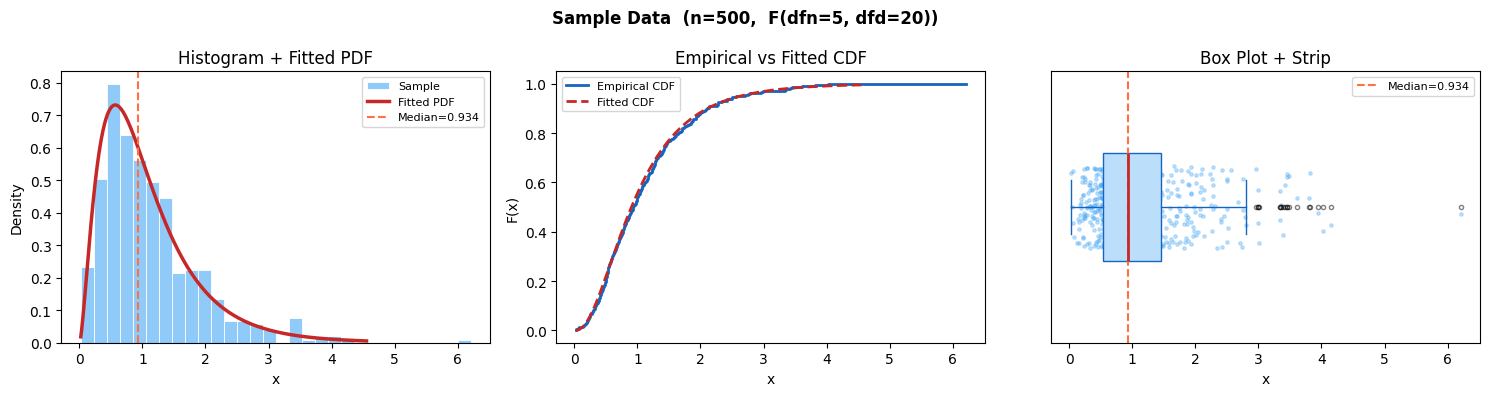

n=500  mean=1.1240  median=0.9345  std=0.7950  skew=1.6504  kurtosis=4.4063


In [3]:
# Sample data plots — F(dfn=5, dfd=20)
np.random.seed(42)
sample_d = stats.f.rvs(dfn=5, dfd=20, size=500)
dfn_hat, dfd_hat, loc_hat, scale_hat = stats.f.fit(sample_d, floc=0, fscale=1)
x_fit = np.linspace(sample_d.min() * 0.9, np.percentile(sample_d, 99) * 1.2, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  F(dfn=5, dfd=20))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.f(dfn_hat, dfd_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.f(dfn_hat, dfd_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Definition** | Ratio of two chi-square variables ÷ their df |
| **Shape** | Right-skewed; becomes more symmetric as $\nu_1, \nu_2 \to \infty$ |
| **ANOVA** | $F = \text{MSB}/\text{MSW}$ — between-group variance / within-group variance |
| **Regression** | $F = \dfrac{R^2/k}{(1-R^2)/(n-k-1)}$ — tests if model explains variance |
| **Variance test** | $F = s_1^2/s_2^2 \sim F(n_1-1, n_2-1)$ under $H_0: \sigma_1^2=\sigma_2^2$ |
| **Reciprocal** | $1/F(\nu_1,\nu_2) \sim F(\nu_2,\nu_1)$ — use upper tail for both-directional variance tests |
| **Relationship** | $t^2(\nu) = F(1, \nu)$ — the t-test is a special case of the F-test |
